# Machine Learning: Supervised & Unsupervised Foundations
**Copyright © 2026 Sujeet Banerjee**  
**Email:** sujee.banerjee@gmail.com

---

Welcome to this guided beginner workbook! In this session, we will explore two core pillars of Machine Learning using Python:
1. **Supervised Learning** (where data has known labels/answers).
2. **Unsupervised Learning** (where the model finds hidden patterns without labels).

## Part A: Linear Regression (Supervised Learning)

**The Objective:** Predict the median house value of California districts based on demographic and geographical features.

**The Goal:** Learn the standard supervised learning workflow: loading data, splitting it into training and testing sets, training a model, and evaluating its accuracy.

### Instructions:
1. **Load the Data:** We will use `fetch_california_housing` from `sklearn.datasets`.
2. **Preprocess:** Separate the features (`X`) from the target label (`y`).
3. **Split:** Use `train_test_split` to keep 20% of the data hidden for testing.
4. **Train:** Initialize a `LinearRegression` model and `.fit()` it to the training data.
5. **Evaluate:** Use the model to predict the test set and calculate the Root Mean Squared Error (RMSE).

### Imports
* Pandas - for data processing
* Scikit Learn (sklearn) - for fetching public data, Test-Train Split, ML Libraries.
* NumPy - for maths operations on the entire data-set
* Matplot Lib - for Scatter Plot.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


### Load the data (public data)
#### Instructions:
* Read the public documents for fetch_california_housing function
* What is a **Data-Set**, **Data-Point** and a **Data-Frame**?
* What are the **features** and **dimensions** in a _data-set_?
* Explore what does the code below ```housing.feature_names[0:6]``` do?
<pre>
# Example
>>> from sklearn.datasets import fetch_california_housing
>>> housing = fetch_california_housing()
>>> print(housing.data.shape, housing.target.shape)
>>> print(housing.feature_names[0:6])
</pre>

In [22]:
# 1. Load the data
print("Loading California Housing Data...")
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name="MedianHouseValue")
print(f"Dataset loaded with {X.shape[0]} rows and {X.shape[1]} features.\n")

Loading California Housing Data...
Dataset loaded with 20640 rows and 8 features.



### Understand the data
* Print all the column names in the data. What does each column represent?
* In the above data, which column represents the **label**?
* Follow the instructions given as the comments in the code-cell below:

In [46]:
# 1. Print first five rows using the 'head' funcion in DataFrame. Read the document on Dataframe.head() function. Try these below:
# print(housing.target_names)
# print(pd.DataFrame(X).head())
print(pd.DataFrame(X).columns)
# pd.DataFrame(Y).head

# 2. Print the number of **rows** and **columns** the data-frame has

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')


### Scatter Plot
#### Instructions:
* Revise the plotting code to make the scatter plot of the dataset (Matplot Lib)

C:\Users\Sujeet\AppData\Local\Temp\ipykernel_16148\3675147931.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


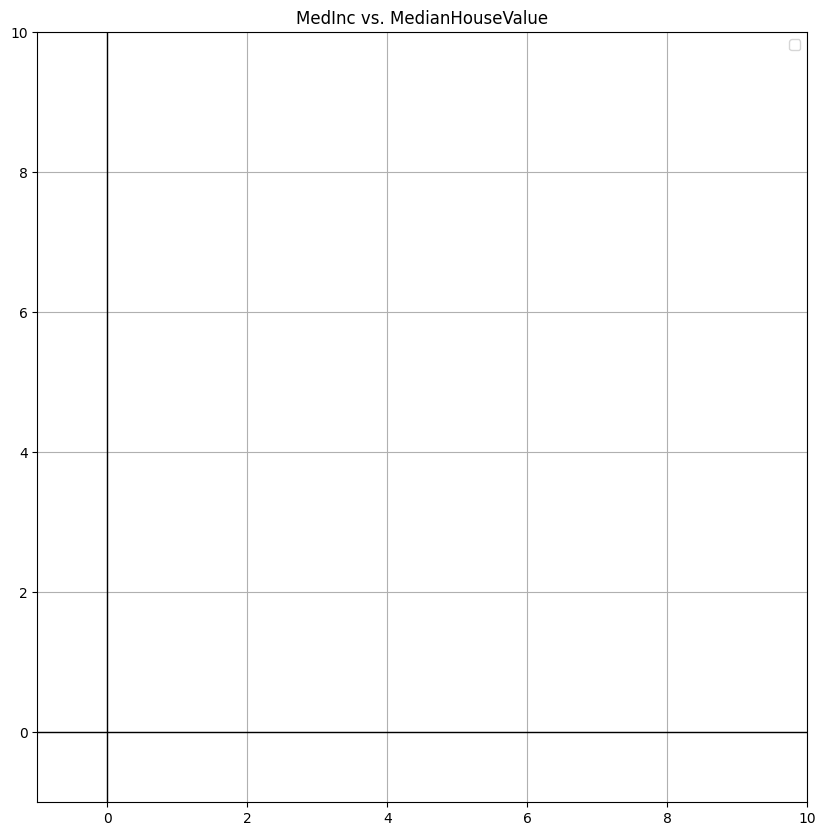

In [91]:
# Scatter plot based on a speci

## Choose a feature (column) as X
## Y value is the label (outcome, or the predicted variable)
column_x1 = 'MedInc'
plt.figure(figsize=(10, 10))
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# Your code to call the plot function:
#---------- your code begins ---------

#---------- your code ends ---------

plt.title(f"{column_x1} vs. {y.name}")
plt.xlim(-1, 10)
plt.ylim(-1, 10)
plt.grid(True)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

# REPEAT THE EXECUTION WITH DIFFERENT COLUMNS TO SEE
# HOW EACH COLUMN (FEATURE) AFFECTS THE HOUSE-PRICE

### Test - Train split
* Why do we need to split the data into two sets - $Test$ and $Train$?
* Follow the instruction given in the comments in the code block below:

In [ ]:

# 2 & 3. Split the data into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the number of data-points in the 'Train' Set
# Your code here:

### Perform Linear Regression!
* Use the **LinearRegression** from Scikit Learn library, and
* Do the line-fitting through the data-point (Training the model)
* Find out from the documents, what does **.fit()** function do?

In [94]:

# 4. Initialize and train the model
model = LinearRegression()
print("Model training starts...\n")
model.fit(X_train, y_train)
print("Model training complete!\n")

Model training starts...

Model training complete!



### Measure the performance of trained model
* To evaluate the model, you need to take the test of the trained model
* The test-dataset you have is like the question-paper, and the model will be graded based on the RSME score (code below)
* What is **MAE**? How is it different from **RSME**?
* Write the code (as instructed in the code comments below) to measure the MAE.

In [95]:
# 5. Make predictions and evaluate
predictions = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print("(This means our model's predictions are off by an average of ~${:.0f} based on the dataset's $100k scaling)".format(rmse * 100000))

# 6 Now compute and pring the MAE
from sklearn.metrics import mean_absolute_error as mae
# Your code to calculate and print the MAE from the
# actual and predicted y values:
#---------- your code begins ---------

#---------- your code ends ---------


Root Mean Squared Error (RMSE): 0.7456
(This means our model's predictions are off by an average of ~$74558 based on the dataset's $100k scaling)


---
## Part B: Support Vector Machine (Unsupervised Learning)

**The Objective:** Identify "anomalous" or highly unusual housing districts in California entirely from the data, without providing any pre-labeled examples of what an anomaly is.

**The Goal:** Learn how an unsupervised technique like **One-Class SVM** can establish a boundary of "normal" data and automatically flag outliers.

### Instructions:
1. **Prep the Data:** We will use the same housing features (`X`) from Part A. Notice we completely ignore the target (`y`) because this is unsupervised!
2. **Scale the Data:** SVMs calculate distances between points, so scaling the data using `StandardScaler` is a mandatory step.
3. **Train the Model:** Initialize a `OneClassSVM`. We will set `nu=0.05` to tell the model we expect roughly 5% of the dataset to be anomalies.
4. **Predict:** Use `.fit_predict()` to flag the data. It will return `1` for normal data and `-1` for anomalies.
5. **Review:** Print out how many anomalies were found.

Side Note:
--
> In data science, we throw the word "anomaly" around a lot, but it can definitely sound like abstract jargon!
> In plain English, an anomaly is just an outlier. It is the "odd one out." It’s a piece of data that completely breaks the normal rules or patterns followed by the rest of the group. In __Unsupervised Learning__, when ML looks at California housing data, it quickly learns what "normal" looks like. For example:
> * Normal Pattern A: If a neighborhood has a very high median income, the houses are usually very expensive.
> * Normal Pattern B: If a neighborhood is packed with massive 6-bedroom houses, it is usually in the suburbs, not in the middle of a dense downtown area.
> An "anomaly" is a neighborhood that shatters those expectations. An example of anomaly: ``` 'A neighborhood where the median income is near the poverty line, but the average house has 9 bedrooms' ```.
> #### Why is this useful in the real world?
Companies use Anomaly Detection (like the Support Vector Machine we built) all the time, not just for houses:
> * **Banking:** "This customer usually buys \\$5 coffees in Seattle. Today they bought a \\$4,000 Rolex in Paris. Flag it as an anomaly! (Fraud detection)."
> * **Manufacturing:** "This machine usually vibrates at this frequency. Today it's vibrating a tiny bit differently. Flag it as an anomaly! (Predictive maintenance before it breaks)."

### Prepare the data, load the libraries
* Follow the instructions given in the comments below.
* Write code as instructed in the comments below.
*

In [133]:
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

# 1. We will use the X_train dataset from above. No labels (y) allowed!

# 2. Scale the data (Mandatory for SVMs to work properly)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# Now write code to make two plots:
#   any column in X_train aginst y_train, and
#   the same column in X_scale aginst y_train
#---------- your code begins ---------
# Hint: X_scaled may be converted to a DataFrame for convenience

#---------- your code ends ---------




### Load and Train the SVM Model

In [153]:
# 3. Initialize the One-Class SVM
# nu=0.05 means we are asking the model to isolate the 5% most unusual districts
svm_model = OneClassSVM(kernel='rbf', gamma='auto', nu=0.05)

# 4. Fit the model and predict anomalies simultaneously
print("Finding anomalies... This may take a few seconds.\n")
anomaly_labels = svm_model.fit_predict(X_scaled)

Finding anomalies... This may take a few seconds.

1


In [139]:

# 5. Analyze the results
# In sklearn, 1 means 'inlier' (normal), and -1 means 'outlier' (anomaly)
normal_count = list(anomaly_labels).count(1)
anomaly_count = list(anomaly_labels).count(-1)

print(f"Total entries analyzed: {len(anomaly_labels)}")
print(f"Normal entries found: {normal_count}")
print(f"Anomalous entries found: {anomaly_count}")

# Now write the code to calculate the percentage of anomalous data,
# predicted by the SVM.
# percent_anomalous =  << Your code here >>
# print(f"Percentage of anomalies: {percent_anomalous:.2f}%")

Total districts analyzed: 16512
Normal districts found: 15687
Anomalous districts found: 825


In [152]:

# Let's peek at the data of the first identified anomaly
anomaly_indices = np.where(anomaly_labels == -1)[0]
#print(f"Anomalous indices found: {anomaly_indices}")
if len(anomaly_indices) > 0:
    print("\nFeatures of the first detected anomaly:")
    print(X_train.iloc[anomaly_indices[0]])


Features of the first detected anomaly:
MedInc           6.426600
HouseAge         5.000000
AveRooms         6.730284
AveBedrms        1.030609
Population    9427.000000
AveOccup         3.394671
Latitude        34.020000
Longitude     -117.790000
Name: 6061, dtype: float64
